# 03 · Stress testing

Stresses the notebook 01 motor model over one future policy-year (EUR). Frequency, severity level and tail shape are handled as separate scenarios.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
require_results('calibrated_model.json')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace

from insurance_model import (
    CalibratedModel, simulate_aggregate_losses, simulate_claims, aggregate, var, es,
)


model = CalibratedModel.from_json(result_path('calibrated_model.json'))
RNG_SEED = 42
N_SIM = 500_000   # matches Notebook 02's chosen baseline size
EUR = lambda v: f"EUR {v:,.0f}"

rng_base = np.random.default_rng(RNG_SEED)
base_losses = simulate_aggregate_losses(N_SIM, model, rng_base)
v_base, e_base, mean_base = var(base_losses, 0.995), es(base_losses, 0.995), base_losses.mean()
print(f"Baseline: mean={EUR(mean_base)}  VaR99.5={EUR(v_base)}  ES99.5={EUR(e_base)}")

Baseline: mean=EUR 350  VaR99.5=EUR 6,247  ES99.5=EUR 45,792


## Severity-level stress

Scaling every claim by the same factor scales aggregate loss, VaR and ES by that factor. Checked with identical random draws.

In [2]:
s_check = 0.5
rng_check = np.random.default_rng(RNG_SEED)
resimulated = simulate_aggregate_losses(N_SIM, model, rng_check, sev_mult=1 + s_check)
v_resim, e_resim = var(resimulated, 0.995), es(resimulated, 0.995)
v_pred, e_pred = v_base * (1 + s_check), e_base * (1 + s_check)
print(f"s = {s_check:.0%}:  re-simulated VaR = {v_resim:,.2f}   analytical (1+s)*VaR_base = {v_pred:,.2f}   match: {np.isclose(v_resim, v_pred)}")
print(f"           re-simulated ES  = {e_resim:,.2f}   analytical (1+s)*ES_base  = {e_pred:,.2f}   match: {np.isclose(e_resim, e_pred)}")

sev_shocks = np.arange(0, 1.01, 0.05)
sev_var = v_base * (1 + sev_shocks)
sev_es = e_base * (1 + sev_shocks)

np.testing.assert_allclose([v_resim, e_resim], [v_pred, e_pred], rtol=1e-12)

s = 50%:  re-simulated VaR = 9,371.10   analytical (1+s)*VaR_base = 9,371.10   match: True
           re-simulated ES  = 68,687.26   analytical (1+s)*ES_base  = 68,687.26   match: True


## Frequency stress

The NB2 mean is raised with dispersion held fixed, and claim counts are re-simulated in each scenario.

In [3]:
freq_shocks = np.arange(0, 1.01, 0.05)
freq_var, freq_es, freq_mean = [], [], []
for i, fs in enumerate(freq_shocks):
    rng_i = np.random.default_rng(RNG_SEED)
    shocked = simulate_aggregate_losses(N_SIM, model, rng_i, freq_mult=1 + fs)
    freq_var.append(var(shocked, 0.995)); freq_es.append(es(shocked, 0.995)); freq_mean.append(shocked.mean())
freq_var, freq_es, freq_mean = map(np.array, (freq_var, freq_es, freq_mean))

print(f"Dispersion r is unchanged across the grid (held fixed at {model.r_freq:.4f}); only lambda is scaled by (1+shock).")
print(f"freq shock 10%:  VaR={freq_var[2]:,.1f}  ({100*(freq_var[2]/v_base-1):+.1f}%)")
print(f"freq shock 100%: VaR={freq_var[-1]:,.1f}  ({100*(freq_var[-1]/v_base-1):+.1f}%)")
np.testing.assert_allclose(freq_var[0], v_base, rtol=1e-12)

Dispersion r is unchanged across the grid (held fixed at 0.7569); only lambda is scaled by (1+shock).
freq shock 10%:  VaR=6,657.1  (+6.6%)
freq shock 100%: VaR=9,790.0  (+56.7%)


## Combined sensitivity

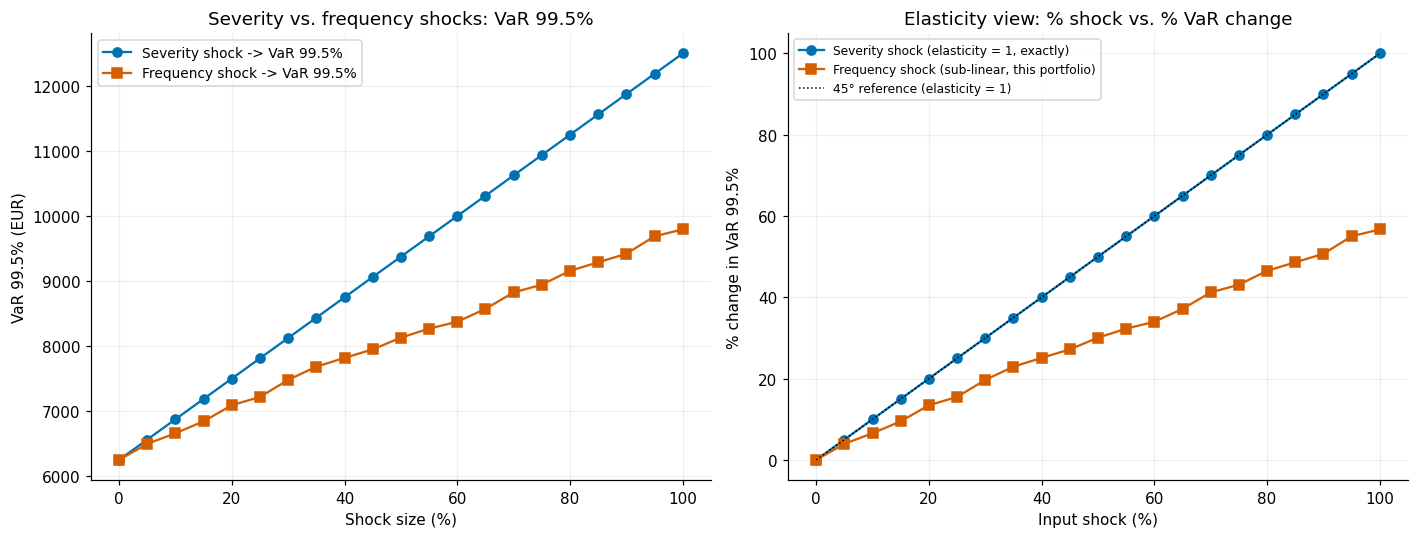

,Shock,Severity elasticity,Frequency elasticity
0,10%,1.000,0.656
1,25%,1.000,0.619
2,50%,1.000,0.601
3,100%,1.000,0.567


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sev_shocks*100, sev_var, 'o-', label='Severity shock -> VaR 99.5%', color='C0')
axes[0].plot(freq_shocks*100, freq_var, 's-', label='Frequency shock -> VaR 99.5%', color='C3')
axes[0].set_xlabel('Shock size (%)'); axes[0].set_ylabel('VaR 99.5% (EUR)')
axes[0].set_title('Severity vs. frequency shocks: VaR 99.5%')
axes[0].legend()

pct_change_sev_var = 100*(sev_var/v_base - 1)
pct_change_freq_var = 100*(freq_var/v_base - 1)
axes[1].plot(sev_shocks*100, pct_change_sev_var, 'o-', color='C0', label='Severity shock (elasticity = 1, exactly)')
axes[1].plot(freq_shocks*100, pct_change_freq_var, 's-', color='C3', label='Frequency shock (sub-linear, this portfolio)')
axes[1].plot([0,100],[0,100],'k:',lw=1, label='45° reference (elasticity = 1)')
axes[1].set_xlabel('Input shock (%)'); axes[1].set_ylabel('% change in VaR 99.5%')
axes[1].set_title('Elasticity view: % shock vs. % VaR change')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

elasticity_table = pd.DataFrame({
    'Shock': [f'{s:.0%}' for s in [0.10, 0.25, 0.50, 1.00]],
    'Severity elasticity': [1.0, 1.0, 1.0, 1.0],
    'Frequency elasticity': [
        (freq_var[freq_shocks==0.10][0]/v_base - 1)/0.10,
        (freq_var[np.isclose(freq_shocks,0.25)][0]/v_base - 1)/0.25,
        (freq_var[freq_shocks==0.50][0]/v_base - 1)/0.50,
        (freq_var[-1]/v_base - 1)/1.00,
    ],
})
elasticity_table.round(3)

The elasticities belong to this model and this grid. Severity scaling is exactly proportional; frequency sensitivity depends on the compound distribution.

## Tail-shape sensitivity

Only the GPD shape changes. Threshold, tail scale and mixture weight stay fixed.

In [5]:
xi_grid = [model.xi_gpd, 0.90, 0.95, 0.99]
xi_rows = []
for xi_new in xi_grid:
    m2 = replace(model, xi_gpd=xi_new)
    rng_xi = np.random.default_rng(RNG_SEED)
    sim_index, severities = simulate_claims(N_SIM, m2, rng_xi)
    losses_xi = aggregate(sim_index, severities, N_SIM)
    xi_rows.append(dict(xi=xi_new, mean=losses_xi.mean(),
                     VaR995=var(losses_xi, 0.995), VaR999=var(losses_xi, 0.999), VaR9995=var(losses_xi, 0.9995),
                     ES995=es(losses_xi, 0.995)))

xi_table = pd.DataFrame(xi_rows)
xi_table['mean_pct_chg'] = 100*(xi_table['mean']/xi_table['mean'].iloc[0] - 1)
xi_table['VaR_pct_chg'] = 100*(xi_table['VaR995']/xi_table['VaR995'].iloc[0] - 1)
xi_table['VaR999_pct_chg'] = 100*(xi_table['VaR999']/xi_table['VaR999'].iloc[0] - 1)
xi_table['VaR9995_pct_chg'] = 100*(xi_table['VaR9995']/xi_table['VaR9995'].iloc[0] - 1)
xi_table['ES_pct_chg'] = 100*(xi_table['ES995']/xi_table['ES995'].iloc[0] - 1)
xi_table.round(2)

,xi,mean,VaR995,VaR999,VaR9995,ES995,mean_pct_chg,VaR_pct_chg,VaR999_pct_chg,VaR9995_pct_chg,ES_pct_chg
0,0.850,350.430,"6,247.400","18,242.540","37,919.790","45,791.510",0.000,0.000,0.000,0.000,0.000
1,0.900,400.620,"6,247.400","18,245.370","38,397.970","55,829.510",14.320,0.000,0.020,1.260,21.920
2,0.950,472.790,"6,247.400","18,248.310","38,909.980","70,264.420",34.920,0.000,0.030,2.610,53.440
3,0.990,550.770,"6,247.400","18,250.680","39,330.570","85,860.600",57.170,0.000,0.040,3.720,87.500


VaR and ES have to be read separately. A heavier far tail can leave a lower quantile untouched while lifting the tail average.

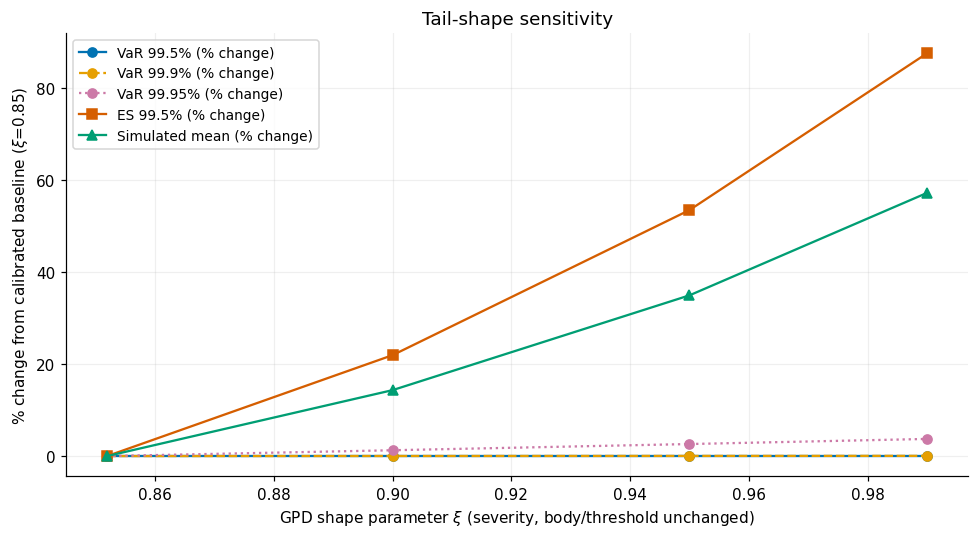

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(xi_table['xi'], xi_table['VaR_pct_chg'], 'o-', label='VaR 99.5% (% change)', color='C0')
ax.plot(xi_table['xi'], xi_table['VaR999_pct_chg'], 'o--', label='VaR 99.9% (% change)', color='C1')
ax.plot(xi_table['xi'], xi_table['VaR9995_pct_chg'], 'o:', label='VaR 99.95% (% change)', color='C4')
ax.plot(xi_table['xi'], xi_table['ES_pct_chg'], 's-', label='ES 99.5% (% change)', color='C3')
ax.plot(xi_table['xi'], xi_table['mean_pct_chg'], '^-', label='Simulated mean (% change)', color='C2')
ax.set_xlabel('GPD shape parameter $\\xi$ (severity, body/threshold unchanged)')
ax.set_ylabel('% change from calibrated baseline ($\\xi$=0.85)')
ax.set_title('Tail-shape sensitivity')
ax.legend()
plt.tight_layout(); plt.show()

How often the annual loss lands in the tail helps place the annual quantiles relative to the severity splice.

In [7]:
p_tail_claim_per_claim = 1 - model.alpha
expected_tail_claims_per_year = model.lambda_freq * p_tail_claim_per_claim
print(f"P(a claim exceeds the threshold)      = {p_tail_claim_per_claim:.4f}  (~{p_tail_claim_per_claim:.1%})")
print(f"E[number of tail claims per year]      = {expected_tail_claims_per_year:.6f}  (~{expected_tail_claims_per_year:.2%})")
print(f"Compare to the VaR quantile levels examined: 0.5%, 0.1%, 0.05%")

P(a claim exceeds the threshold)      = 0.0100  (~1.0%)
E[number of tail claims per year]      = 0.001026  (~0.10%)
Compare to the VaR quantile levels examined: 0.5%, 0.1%, 0.05%


The tail-claim probability is for a single policy-year. The same quantile behavior shouldn't be assumed for a larger book.

## Illustrative model comparison

The motor fit is compared with a made-up high-frequency, thin-tail Poisson/lognormal example. The example is synthetic, not a fitted insurer.

In [8]:
def simulate_toy(n_sim, lam, sigma_ln, freq_mult=1.0, seed=7):
    rng = np.random.default_rng(seed)
    n_claims = rng.poisson(lam * freq_mult, size=n_sim)
    total = int(n_claims.sum())
    sev = rng.lognormal(mean=0, sigma=sigma_ln, size=total)
    idx = np.repeat(np.arange(n_sim), n_claims)
    return np.bincount(idx, weights=sev, minlength=n_sim)

toy_base = simulate_toy(N_SIM, lam=20.0, sigma_ln=0.05)
toy_shocked = simulate_toy(N_SIM, lam=20.0, sigma_ln=0.05, freq_mult=1.10, seed=555)
toy_v_base, toy_v_shocked = var(toy_base, 0.995), var(toy_shocked, 0.995)
toy_freq_elasticity_10pct = (toy_v_shocked/toy_v_base - 1)/0.10
motor_freq_elasticity_10pct = (freq_var[freq_shocks==0.10][0]/v_base - 1)/0.10

comparison = pd.DataFrame({
    'Portfolio': ['This motor book (lambda~0.10, GPD tail xi~0.85)',
                  'Illustrative high-frequency / thin-tail book (lambda=20, lognormal sigma=0.05)'],
    'Frequency elasticity @ 10% shock': [motor_freq_elasticity_10pct, toy_freq_elasticity_10pct],
    'Severity elasticity (always)': [1.0, 1.0],
})
comparison

,Portfolio,Frequency elasticity @ 10% shock,Severity elasticity (always)
0,"This motor book (lambda~0.10, GPD tail xi~0.85)",0.656,1.000
1,Illustrative high-frequency / thin-tail book (...,0.829,1.000


Frequency elasticity depends on the assumed loss model. The toy case illustrates that; it isn't further evidence.

## Stress comparison

In [9]:
from insurance_model import severity_mean
freq_es_multiseed_base, freq_es_multiseed_shocked = [], []
for i in range(15):
    rb = np.random.default_rng(5000 + i)
    lb = simulate_aggregate_losses(N_SIM, model, rb)
    rs = np.random.default_rng(6000 + i)
    ls = simulate_aggregate_losses(N_SIM, model, rs, freq_mult=1.10)
    freq_es_multiseed_base.append(es(lb, 0.995))
    freq_es_multiseed_shocked.append(es(ls, 0.995))
freq_es_pct_chg_stable = 100 * (np.mean(freq_es_multiseed_shocked) / np.mean(freq_es_multiseed_base) - 1)
print(f"Frequency +10% -> ES 99.5% % change, averaged over 15 seeds: {freq_es_pct_chg_stable:+.2f}%")
print('Across-seed averaging does not remove parameter uncertainty.')

stress_comparison = pd.DataFrame({
    'Stress type': [
        '(A) Frequency +10%',
        '(B) Severity level +10%',
        '(C) Tail-shape: xi 0.85 -> 0.90',
    ],
    'What it changes': [
        'Claim rate (lambda) only',
        'Every claim size, proportionally (body + tail)',
        'GPD tail shape only (ordinary claims unaffected)',
    ],
    'Mean % change': [
        100 * 0.10,  # exact via Wald's identity, E[N] scaled by 1.10
        100 * 0.10,  # exact via Wald's identity, E[X] scaled by 1.10
        100 * (severity_mean(replace(model, xi_gpd=.90)) / severity_mean(model) - 1),
    ],
    'VaR 99.5% % change': [
        100 * (freq_var[freq_shocks == 0.10][0] / v_base - 1),
        100 * 0.10,
        xi_table.loc[xi_table['xi'] == 0.90, 'VaR_pct_chg'].iloc[0],
    ],
    'ES 99.5% % change': [
        freq_es_pct_chg_stable,  # 15-seed average, see note above
        100 * 0.10,
        xi_table.loc[xi_table['xi'] == 0.90, 'ES_pct_chg'].iloc[0],
    ],
})
stress_comparison.round(2)
json.dump({'currency':'EUR', 'horizon':'one policy-year', 'comparison':stress_comparison.to_dict('records')}, open(result_path('stress_results.json'),'w'), indent=2)
record_results('stress_results.json')

Frequency +10% -> ES 99.5% % change, averaged over 15 seeds: -2.27%
Across-seed averaging does not remove parameter uncertainty.


Analytical means isolate each scenario's effect on expected cost. The simulated tail figures still carry Monte Carlo error.

## Interpretation

Frequency and severity-level shocks stand for changes in insured loss experience. A tail-shape change is partly model uncertainty.

## Notes

- +10% frequency: mean +10%, VaR 99.5% +6.6%. The −2.3% ES change in that case is simulation noise; ES is too unstable at this tail to read.
- +10% severity: mean, VaR and ES all +10%.
- ξ from 0.85 to 0.90: the analytical mean rises 19.6%, the simulated mean 14.3% with this seed (short of the analytical figure because of heavy-tail sampling, see 02), ES 21.9%, VaR unchanged with this seed.
- This is stress testing, not backtesting.